# MO434 — Análise Comparativa de Modelos Destilados
### Maiara Araujo Damião — RA 291674 | IC-UNICAMP 2026

Este notebook permite **carregar todos os modelos salvos** e realizar uma análise comparativa completa entre:
- **ResNet18** (student backbone principal)  
- **Lighter Encoder** (backbone alternativo)
- Teacher (referência)

**Métodos avaliados:** KD, FitNet, AT, RKD, DKD, Pré-GAP (MSE+CE), Pós-GAP (MSE+CE), Pré-GAP (MSE), Pós-GAP (MSE)


## 1. Instalação de Dependências

In [6]:
!pip install grad-cam torchsummary thop umap-learn -q

## 2. Imports

In [7]:
import os, json, copy, re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    top_k_accuracy_score, cohen_kappa_score,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from thop import profile

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [8]:
# ──────────────────────────────────────────────────────────
# Hiperparâmetros globais
# ──────────────────────────────────────────────────────────
SEED = 12
torch.manual_seed(SEED) # Do próprio https://docs.pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

BATCH_SIZE      = 32
NUM_WORKERS     = 2
N_TRAIN         = 0.7
N_VAL           = 0.15

# ── Constantes globais do student ─────────────────────────────────────────────
STUDENT_DIM             = 512          # dimensão de saída do encoder (ResNet18 e LightCNN)
STUDENT_GUIDED_CHANNELS = 128          # canais da camada guia para FitNet
STUDENT_GUIDED_LAYER    = "layer3"     # chave da camada guia (ResNet18) / "block3" (LightCNN)
STUDENT_AT_FEAT_KEYS    = {
    "resnet18": ("ResNet18", ["layer2", "layer3", "layer4"]),
    "lightcnn": ("LightCNN", ["block2", "block3", "block4"]),
}

# Alias para manter compatibilidade (prep_student == prep)
# será redefinido após prep ser criado, mas declaramos aqui para evitar NameError
prep_student = None

## 3. Montagem do Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')
PATH = "/content/drive/My Drive/Colab Notebooks/MO434"
print(f"📁 Caminho base: {PATH}")
print("Arquivos encontrados:")
try:
    files = os.listdir(PATH)
    for f in sorted(files):
        print(f"  - {f}")
except Exception as e:
    print(f"Erro ao listar: {e}")


Mounted at /content/drive
📁 Caminho base: /content/drive/My Drive/Colab Notebooks/MO434
Arquivos encontrados:
  - results_summary.json
  - student_garbage_ResNet50_LightCNN_AT.pth
  - student_garbage_ResNet50_LightCNN_AT_postgap.pth
  - student_garbage_ResNet50_LightCNN_DKD.pth
  - student_garbage_ResNet50_LightCNN_DKD_postgap.pth
  - student_garbage_ResNet50_LightCNN_ExperimentoPostgap.pth
  - student_garbage_ResNet50_LightCNN_ExperimentoPostgap2.pth
  - student_garbage_ResNet50_LightCNN_ExperimentoPregap.pth
  - student_garbage_ResNet50_LightCNN_ExperimentoPregap2.pth
  - student_garbage_ResNet50_LightCNN_KD.pth
  - student_garbage_ResNet50_LightCNN_KD_postgap.pth
  - student_garbage_ResNet50_LightCNN_RKD.pth
  - student_garbage_ResNet50_LightCNN_RKD_postgap.pth
  - student_garbage_ResNet50_LightCNN_fitnet.pth
  - student_garbage_ResNet50_LightCNN_fitnet_postgap.pth
  - student_garbage_ResNet50_Resnet18_AT.pth
  - student_garbage_ResNet50_Resnet18_AT_postgap.pth
  - student_garbage_R

## 4. Carregamento dos Datasets

In [10]:
!pip install -q kaggle
!mkdir -p ~/.kaggle && echo KGAT_b8ebbeea69049704aeb16173a885dd6e > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

!kaggle datasets download -d prasunroy/natural-images
!unzip -q natural-images.zip -d ./natural-images

!kaggle datasets download -d mostafaabla/garbage-classification
!unzip -q garbage-classification.zip -d ./garbage

DATASET_NATURAL = "./natural-images/natural_images"
DATASET_GARBAGE = "./garbage/garbage_classification"

Dataset URL: https://www.kaggle.com/datasets/prasunroy/natural-images
License(s): CC-BY-NC-SA-4.0
100% 342M/342M [00:21<00:00, 16.7MB/s]

Dataset URL: https://www.kaggle.com/datasets/mostafaabla/garbage-classification
License(s): ODbL-1.0
100% 239M/239M [00:14<00:00, 17.2MB/s]



In [11]:
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

studentweights = models.ResNet18_Weights.IMAGENET1K_V1
_t = studentweights.transforms()   # Resize(256) + CenterCrop(224) + Normalize

prep = transforms.Compose([
    transforms.Resize(_t.resize_size),          # 256
    transforms.CenterCrop(_t.crop_size[0]),     # 224
    transforms.ToTensor(),
    transforms.Normalize(mean=_t.mean, std=_t.std),
])
prep_student = prep

In [12]:
print(prep_student)

Compose(
    Resize(size=[256], interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [13]:
# ──────────────────────────────────────────────────────────
# Pesos e dataloaders (ResNet50)
# ──────────────────────────────────────────────────────────

resNet50weights = models.ResNet50_Weights.IMAGENET1K_V2
print(resNet50weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [14]:
# normalização
prep_resNet50 = resNet50weights.transforms();

# data augmentation
aug_resNet50 = transforms.Compose([
    transforms.Resize(prep_resNet50.resize_size),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.05, 0.10),
        scale=(0.9, 1.1),
        shear=(-2, 2)
    ),
    transforms.CenterCrop(prep_resNet50.crop_size[0]),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=prep_resNet50.mean,
        std=prep_resNet50.std
    )
])

In [15]:
def count_params(model):
    """Retorna o total de parâmetros do modelo."""
    return sum(p.numel() for p in model.parameters())


def calc_gflops(model, input_hw=(224, 224)):
    """Calcula GFLOPs usando thop. Retorna nan em caso de erro."""
    try:
        dummy = torch.randn(1, 3, *input_hw).to(device)
        flops, _ = profile(model, inputs=(dummy,), verbose=False)
        return flops / 1e9
    except Exception:
        return float("nan")


def get_pre_gap_features_shape(model, input_hw=(224, 224)):
    """Retorna a shape pré-GAP de um modelo no formato 'H × W × C'."""
    model.eval()
    hooks, shapes = [], []

    def _hook(m, inp, out):
        shapes.append(out.shape)

    # Registra hook na camada de pooling global
    pool_layer = None
    if hasattr(model, "avgpool"):
        pool_layer = model.avgpool
    elif hasattr(model, "gap"):
        pool_layer = model.gap

    if pool_layer is not None:
        h = pool_layer.register_forward_pre_hook(lambda m, inp: shapes.append(inp[0].shape))
        with torch.no_grad():
            dummy = torch.randn(1, 3, *input_hw).to(device)
            model(dummy)
        h.remove()
        if shapes:
            s = shapes[0]  # (B, C, H, W)
            return f"{s[2]} × {s[3]} × {s[1]}"
    return "N/A"

def get_loader(dataset_root, prep):
    from torch.utils.data import Subset
    np.random.seed(SEED)
    base     = datasets.ImageFolder(root=dataset_root)
    n        = len(base)
    indices  = np.random.permutation(n)
    n_train  = int(N_TRAIN * n)
    n_val    = int(N_VAL   * n)
    test_idx = indices[n_train + n_val:]

    test_dataset = datasets.ImageFolder(root=dataset_root, transform=prep)
    test_set     = Subset(test_dataset, test_idx)
    loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return loader, base.classes

try:
    test_loader_nat_teacher,  classes_nat  = get_loader(DATASET_NATURAL,  prep_resNet50)
    test_loader_nat_student,  _            = get_loader(DATASET_NATURAL,  prep_student)

    test_loader_garb_teacher, classes_garb = get_loader(DATASET_GARBAGE,  prep_resNet50)
    test_loader_garb_student, _            = get_loader(DATASET_GARBAGE,  prep_student)
    print(f"✅ Natural Images : {len(classes_nat)} classes")
    print(f"✅ Garbage        : {len(classes_garb)} classes")
except Exception as e:
    print(f"⚠️  Datasets não encontrados: {e}")

✅ Natural Images : 8 classes
✅ Garbage        : 12 classes


## 5. Definição das Arquiteturas (Encoder + Predictor)

In [16]:
class LightCNNEncoder(nn.Module):
    """
    Encoder CNN leve para 224×224 → (B, 512, 1, 1).

    Arquitetura:
      stem   : Conv 3→16,  3×3, stride 2 → 112×112   (416 params)
      block1 : Conv 16→32, 3×3, stride 2 →  56×56    (4.6K params)
      block2 : Conv 32→64, 3×3, stride 2 →  28×28    (18.5K params)
      block3 : Conv 64→128,3×3, stride 2 →  14×14    (73.8K params)
      block4 : Conv 128→256,3×3,stride 2 →   7×7     (295K params)
      head   : Conv 256→512,1×1, stride 1 →   7×7    (131K params)
      gap    : AdaptiveAvgPool → (B, 512, 1, 1)

    Total: ~176K parâmetros treináveis.
    Sem pesos pré-treinados — treinado do zero junto com a destilação.
    """

    def _block(self, in_ch, out_ch, stride=2):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3,
                      stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def __init__(self):
        super().__init__()
        self.stem   = self._block(3,   16,  stride=2)   # 224 → 112
        self.block1 = self._block(16,  32,  stride=2)   # 112 →  56
        self.block2 = self._block(32,  64,  stride=2)   #  56 →  28
        self.block3 = self._block(64,  128, stride=2)   #  28 →  14
        self.block4 = self._block(128, 256, stride=2)   #  14 →   7
        self.head   = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )
        self.gap    = nn.AdaptiveAvgPool2d((1, 1))      #   7 →   1

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.head(x)
        x = self.gap(x)      # (B, 512, 1, 1) — mesma forma do ResNet18
        return x

# ──────────────────────────────────────────────────────────
# Encoder do student
# ──────────────────────────────────────────────────────────
def build_student_encoder(device=device):
    if(STUDENT_BACKBONE == "resnet18"):
      base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
      encoder = nn.Sequential(*list(base.children())[:-1]).to(device)
      # saída: (B, 512, 1, 1) — use .flatten(1) para obter (B, 512)
    elif STUDENT_BACKBONE == "lightcnn":
        encoder = LightCNNEncoder().to(device)
    else:
      raise ValueError(f"Modelo ainda não suportado: {modelo}")
    return encoder

# ──────────────────────────────────────────────────────────
# Predictors genéricos — recebem as dimensões como parâmetro
# ──────────────────────────────────────────────────────────
class PredictorPreGAP(nn.Module):
    def __init__(self, in_dim, out_channels, spatial):
        super().__init__()
        # in_dim=512, out_channels=2048, spatial=7
        mid = 512
        self.net = nn.Sequential(
            # (B, 512, 1, 1) → (B, 512, 7, 7)  via upsample + conv
            nn.Upsample(size=(spatial, spatial), mode='bilinear', align_corners=False),
            nn.Conv2d(in_dim, mid, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid),
            nn.GELU(),
            #nn.ReLU(),
            # (B, 512, 7, 7) → (B, out_channels, 7, 7)
            nn.Conv2d(mid, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        # x: (B, 512, 1, 1) — saída do ResNet18 encoder
        return self.net(x)


class PredictorPostGAP(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, max(in_dim, out_dim)),
            nn.BatchNorm1d(max(in_dim, out_dim)),
            nn.GELU(),
            #nn.ReLU(),
            nn.Linear(max(in_dim, out_dim), out_dim),
        )

    def forward(self, x):
        return self.net(x.flatten(1))   # (B, out_dim)

class FitNetRegressor(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.regressor = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))
    def forward(self, x):
        return self.regressor(x)

In [17]:
# ──────────────────────────────────────────────────────────
# Fábrica: cria encoder + predictor correto para o teacher atual
# ──────────────────────────────────────────────────────────
def build_student_and_predictors(teacher_model, device=device):
    pre_gap_shape, post_gap_dim = get_teacher_output_shapes(teacher_model, device=device)
    t_channels, t_h, t_w = pre_gap_shape

    encoder      = build_student_encoder(device)
    pred_pregap  = PredictorPreGAP(in_dim=STUDENT_DIM, out_channels=t_channels, spatial=t_h).to(device)
    pred_postgap = PredictorPostGAP(in_dim=STUDENT_DIM, out_dim=post_gap_dim).to(device)

    # FitNet: canais da hint do teacher dependem da arquitetura
    if isinstance(teacher_model, torchvision.models.ResNet):
        HINT_CHANNELS = 1024   # layer3 do ResNet50
    elif isinstance(teacher_model, torchvision.models.ConvNeXt):
        HINT_CHANNELS = 384    # stage1 do ConvNeXt-Base
    else:
        HINT_CHANNELS = 256    # VGG
    reg_fitnet = FitNetRegressor(in_channels=STUDENT_GUIDED_CHANNELS, out_channels=HINT_CHANNELS).to(device)

    print(f"Teacher pré-GAP : {pre_gap_shape}")
    print(f"Teacher pós-GAP : {post_gap_dim}")
    print(f"PredictorPreGAP : {STUDENT_DIM} → {t_channels}×{t_h}×{t_w}")
    print(f"PredictorPostGAP: {STUDENT_DIM} → {post_gap_dim}")
    print(f"FitNetRegressor  : {STUDENT_GUIDED_CHANNELS} → {HINT_CHANNELS} "
          f"({STUDENT_GUIDED_LAYER}_student → hint_teacher)")

    return encoder, pred_pregap, pred_postgap, reg_fitnet

# Load student_model
def load_student_classification_model(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    class_labels = ckpt.get("num_classes", None) # This is a list of class names
    num_output_features = len(class_labels) if class_labels else 1000 # Default to 1000 if not found, but it should be present

    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_output_features)

    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    history = ckpt.get("history", None)

    print("\nModel loaded successfully!")
    if history:
        print("Training History:")
        print(f"  Best Validation Accuracy: {history['best_val_acc']:.4f}")
        print(f"  Best Validation Loss: {history['best_val_loss']:.4f}")
        print(f"  Achieved at Epoch: {history['best_epoch']}")
    else:
        print("No training history found in the checkpoint.")

    return model, history, class_labels

# Load distillation_model
def load_student_distillation_model(checkpoint_path, device, mode="combined",
                                    extract_classifier=None):
    ckpt = torch.load(checkpoint_path, map_location=device)
    num_classes    = len(ckpt["num_classes"])
    history        = ckpt.get("history", None)
    class_labels   = ckpt["num_classes"]

    # Helper to clean state_dict from non-model keys (e.g., from thop)
    def clean_state_dict(state_dict):
        cleaned_state_dict = type(state_dict)() # Create an empty ordered dict
        for k, v in state_dict.items():
            if not re.match(r'.*total_ops|.*total_params', k):
                cleaned_state_dict[k] = v
        return cleaned_state_dict

    # ── modelos simples (student baseline sem destilação) ──────────────
    if "encoder_state_dict" not in ckpt:
        if STUDENT_BACKBONE == "resnet18":
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif STUDENT_BACKBONE == "lightcnn":
            model = LightCNNEncoder()
            model.gap = nn.AdaptiveAvgPool2d((1, 1))
            model.fc = nn.Linear(512, num_classes)

        model.load_state_dict(ckpt["model_state_dict"])
        model.to(device).eval()
        if mode == "parts":
            return model, None, history
        return model, history, class_labels

    encoder   = build_student_encoder(device)
    encoder_state_dict = clean_state_dict(ckpt["encoder_state_dict"])
    encoder.load_state_dict(encoder_state_dict)
    encoder.to(device).eval()

    # O predictor precisa ser reconstruído com as dimensões certas
    pre_gap_shape, post_gap_dim = get_teacher_output_shapes(
        teacher_model_natural_trained, device=device)
    t_channels, t_h, _ = pre_gap_shape

    # Decide o tipo de predictor pela shape salva
    pred_state = clean_state_dict(ckpt["predictor_state_dict"])

    # Corrected logic to determine predictor type
    # PredictorPreGAP has nn.Conv2d at net.1, which has 'weight' of dim 4
    if "net.1.weight" in pred_state and pred_state["net.1.weight"].dim() == 4:
        # This is a PredictorPreGAP
        predictor = PredictorPreGAP(STUDENT_DIM, t_channels, t_h).to(device)
    else:
        # This is a PredictorPostGAP
        predictor = PredictorPostGAP(STUDENT_DIM, post_gap_dim).to(device)
    predictor.load_state_dict(pred_state)
    predictor.eval()

    if mode == "parts":
        return encoder, predictor, history

    # reconstrói o CombinedStudentModel
    combined = CombinedStudentModelForMetrics.__new__(CombinedStudentModelForMetrics)
    nn.Module.__init__(combined)
    combined.encoder    = encoder
    combined.predictor  = predictor
    if(extract_classifier == None):
      combined.classifier = natural_extract_classifier
    else:
      combined.classifier = extract_classifier
    combined_model_state_dict = clean_state_dict(ckpt["model_state_dict"])
    combined.load_state_dict(combined_model_state_dict)
    combined.to(device).eval()
    combined.load_state_dict(combined_model_state_dict, strict=False)

    if mode == "all":
        return combined, encoder, predictor, history, class_labels
    return combined, history, class_labels

### Funções

In [18]:
# ──────────────────────────────────────────────────────────
# Extração de encoder e classificador
# (usados fixos nas Fases 2 e 3)
# ──────────────────────────────────────────────────────────

def extract_encoder(teacher_model):
    encoder = nn.Sequential(*list(teacher_model.children())[:-1]).to(device)
    for p in encoder.parameters():
        p.requires_grad = False
    return encoder

def extract_classifier(teacher_model):
    if hasattr(teacher_model, "fc"):  # ResNet
        classifier = copy.deepcopy(teacher_model.fc)

    elif isinstance(teacher_model, torchvision.models.VGG):  # VGG
        classifier = copy.deepcopy(teacher_model.classifier[-1])

    elif hasattr(teacher_model, "classifier"):  # ConvNeXt
        cls = teacher_model.classifier

        if isinstance(teacher_model, torchvision.models.ConvNeXt):
            classifier = copy.deepcopy(cls[-1])
        else:
            raise ValueError("Classifier head não reconhecido")

    else:
        raise ValueError("Classifier head não reconhecido")

    for p in classifier.parameters():
        p.requires_grad = False

    return classifier

def get_teacher_features(teacher_model, x):
    """
    Retorna (pre_gap, post_gap, logits, intermediate_feats) sem gradiente.
      pre_gap           : (B, C, H, W)  — saída antes do avgpool
      post_gap          : (B, C)        — saída depois do avgpool (embedding)
      logits            : (B, num_cls)
      intermediate_feats: list de tensores (B, C_i, H_i, W_i) — usados no AT
    """
    teacher_model.eval()
    with torch.no_grad():

        # ── ConvNeXt ──────────────────────────────────────────────────────────
        if isinstance(teacher_model, torchvision.models.ConvNeXt):
            # Percorre os 8 sub-módulos de teacher_model.features
            # e guarda as saídas após os stages convolucionais (índices 1, 3, 5).
            z = x
            intermediate_feats = []
            for i, layer in enumerate(teacher_model.features):
                z = layer(z)
                if i in (1, 3, 5):      # após stage 0, 1, 2
                    intermediate_feats.append(z)
            pre_gap  = z                # após features[-1] = stage 3 + LayerNorm
            post_gap = teacher_model.avgpool(pre_gap).flatten(1)
            logits   = teacher_model.classifier(post_gap)

        # ── ResNet50 / ResNet18 ───────────────────────────────────────────────
        elif isinstance(teacher_model, torchvision.models.ResNet):
            z  = teacher_model.conv1(x)
            z  = teacher_model.bn1(z)
            z  = teacher_model.relu(z)
            z  = teacher_model.maxpool(z)
            f1 = teacher_model.layer1(z)
            f2 = teacher_model.layer2(f1)
            f3 = teacher_model.layer3(f2)
            f4 = teacher_model.layer4(f3)
            pre_gap           = f4
            post_gap          = teacher_model.avgpool(pre_gap).flatten(1)
            logits            = teacher_model.fc(post_gap)
            intermediate_feats = [f2, f3, f4]   # 3 estágios intermediários

        # ── VGG ──────────────────────────────────────────────────────────────
        elif isinstance(teacher_model, torchvision.models.VGG):
            feats = teacher_model.features
            intermediate_feats = []
            z = x
            block_ends = [4, 9, 16, 23, 30]   # índices após cada maxpool no VGG16
            for i, layer in enumerate(feats):
                z = layer(z)
                if i in block_ends[1:4]:       # 3 stages intermediários
                    intermediate_feats.append(z)
            pre_gap  = z
            post_gap = teacher_model.avgpool(pre_gap).flatten(1)
            logits   = teacher_model(x)

        else:
            raise ValueError(f"Teacher não suportado: {type(teacher_model)}")

    return pre_gap, post_gap, logits, intermediate_feats

class CombinedStudentModelForMetrics(nn.Module):
    """
    Junta encoder + predictor + classifier numa única forward.
    - encoder   : ResNet18 sem fc → (B, 512, 1, 1)
    - predictor : PredictorPostGAP → (B, post_gap_dim)
                  PredictorPreGAP  → (B, C, H, W)
    - classifier: camada Linear do teacher, congelada    → (B, num_classes)
    """
    VALID_MODES = {"encoder_pregap", "encoder_postgap"}

    def __init__(self, encoder, predictor, classifier, mode="encoder_pregap"):
        super().__init__()
        self.encoder    = encoder
        self.predictor  = predictor
        self.classifier = classifier
        # The 'mode' attribute is now less critical as forward will adapt
        # but keep it for potential future use or debugging
        mode = mode.lower()
        assert mode in self.VALID_MODES, f"Modo inválido: {mode}"
        self.mode = mode

    def forward(self, x):
        feat = self.encoder(x)
        pred = self.predictor(feat)

        if pred.dim() == 4: # This is a feature map (e.g., from PredictorPreGAP)
            pooled = F.adaptive_avg_pool2d(pred, (1, 1)).flatten(1)
        elif pred.dim() == 2: # This is already a vector (e.g., from PredictorPostGAP)
            pooled = pred
        else:
            raise ValueError(f"Unexpected predictor output dimension: {pred.dim()}")

        return self.classifier(pooled)

# Load student_model
def load_student_classification_model(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    class_labels = ckpt.get("num_classes", None) # This is a list of class names
    num_output_features = len(class_labels) if class_labels else 1000 # Default to 1000 if not found, but it should be present

    model = torchvision.models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_output_features)

    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    history = ckpt.get("history", None)

    print("\nModel loaded successfully!")
    if history:
        print("Training History:")
        print(f"  Best Validation Accuracy: {history['best_val_acc']:.4f}")
        print(f"  Best Validation Loss: {history['best_val_loss']:.4f}")
        print(f"  Achieved at Epoch: {history['best_epoch']}")
    else:
        print("No training history found in the checkpoint.")

    return model, history, class_labels

# Load distillation_model
def load_student_distillation_model(checkpoint_path, device, mode="combined",
                                    extract_classifier=None):
    ckpt = torch.load(checkpoint_path, map_location=device)
    num_classes    = len(ckpt["num_classes"])
    history        = ckpt.get("history", None)
    class_labels   = ckpt["num_classes"]

    # Helper to clean state_dict from non-model keys (e.g., from thop)
    def clean_state_dict(state_dict):
        cleaned_state_dict = type(state_dict)() # Create an empty ordered dict
        for k, v in state_dict.items():
            if not re.match(r'.*total_ops|.*total_params', k):
                cleaned_state_dict[k] = v
        return cleaned_state_dict

    # ── modelos simples (student baseline sem destilação) ──────────────
    if "encoder_state_dict" not in ckpt:
        if STUDENT_BACKBONE == "resnet18":
            model = models.resnet18(weights=None)
            model.fc = nn.Linear(model.fc.in_features, num_classes)
        elif STUDENT_BACKBONE == "lightcnn":
            model = LightCNNEncoder()
            model.gap = nn.AdaptiveAvgPool2d((1, 1))
            model.fc = nn.Linear(512, num_classes)

        model.load_state_dict(clean_state_dict(ckpt["model_state_dict"]))
        model.to(device).eval()
        if mode == "parts":
            return model, None, history
        return model, history, class_labels

    encoder   = build_student_encoder(device)
    encoder_state_dict = clean_state_dict(ckpt["encoder_state_dict"])
    encoder.load_state_dict(encoder_state_dict)
    encoder.to(device).eval()

    # O predictor precisa ser reconstruído com as dimensões certas
    pre_gap_shape, post_gap_dim = get_teacher_output_shapes(
        teacher_model_natural_trained, device=device)
    t_channels, t_h, _ = pre_gap_shape

    # Decide o tipo de predictor pela shape salva
    pred_state = clean_state_dict(ckpt["predictor_state_dict"])

    # Corrected logic to determine predictor type
    # PredictorPreGAP has nn.Conv2d at net.1, which has 'weight' of dim 4
    if "net.1.weight" in pred_state and pred_state["net.1.weight"].dim() == 4:
        # This is a PredictorPreGAP
        predictor = PredictorPreGAP(STUDENT_DIM, t_channels, t_h).to(device)
    else:
        # This is a PredictorPostGAP
        predictor = PredictorPostGAP(STUDENT_DIM, post_gap_dim).to(device)
    predictor.load_state_dict(pred_state)
    predictor.eval()

    if mode == "parts":
        return encoder, predictor, history

    # reconstrói o CombinedStudentModel
    combined = CombinedStudentModelForMetrics.__new__(CombinedStudentModelForMetrics)
    nn.Module.__init__(combined)
    combined.encoder    = encoder
    combined.predictor  = predictor
    if(extract_classifier == None):
      combined.classifier = natural_extract_classifier
    else:
      combined.classifier = extract_classifier
    combined_model_state_dict = clean_state_dict(ckpt["model_state_dict"])
    combined.load_state_dict(combined_model_state_dict)
    combined.to(device).eval()

    if mode == "all":
        return combined, encoder, predictor, history, class_labels
    return combined, history, class_labels

def _to_vector(pred):
    """
    Garante que pred seja um vetor (B, D).
    - Se pred é (B, C, H, W) → GAP → flatten → (B, C)
    - Se pred é (B, D)        → retorna direto
    """
    if pred.dim() == 4:
        return F.adaptive_avg_pool2d(pred, (1, 1)).flatten(1)
    return pred  # já é (B, D)

def get_student_intermediate_feats(modelo, student_encoder, images):
  feats = {}

  if(modelo == "ResNet18"):
    """Extrai features intermediárias do encoder ResNet18 do student."""
    x    = student_encoder[0](images)  # conv1
    x    = student_encoder[1](x)       # bn1
    x    = student_encoder[2](x)       # relu
    x    = student_encoder[3](x)       # maxpool
    f1   = student_encoder[4](x)       # layer1
    f2   = student_encoder[5](f1)      # layer2
    f3   = student_encoder[6](f2)      # layer3
    f4   = student_encoder[7](f3)      # layer4

    return {"layer1": f1,
            "layer2": f2,
            "layer3": f3,
            "layer4": f4,
            "final":  f4}

  elif(modelo == "LightCNN"):
    z = student_encoder.stem(images)
    z = student_encoder.block1(z); feats["block1"] = z
    z = student_encoder.block2(z);  feats["block2"] = z
    z = student_encoder.block3(z);  feats["block3"] = z
    z = student_encoder.block4(z);  feats["block4"] = z
    z = student_encoder.head(z)
    z = student_encoder.gap(z)

    return {"block1": feats["block1"],
          "block2": feats["block2"],
          "block3": feats["block3"],
          "block4": feats["block4"],
          "final": feats["block4"]}

  else:
    raise ValueError(f"Modelo ainda não suportado: {modelo}")

In [19]:
# ──────────────────────────────────────────────────────────
# Utilitário: descobre shapes do teacher automaticamente
# ──────────────────────────────────────────────────────────
def get_teacher_output_shapes(teacher_model, input_size=(3, 224, 224), device=device):
    """
    Retorna (pre_gap_shape, post_gap_dim) do teacher.
    pre_gap_shape : tupla (C, H, W)
    post_gap_dim  : int
    """
    teacher_model.eval()
    dummy = torch.zeros(1, *input_size).to(device)
    with torch.no_grad():
        pre_gap, post_gap, _, _ = get_teacher_features(teacher_model, dummy)
    pre_gap_shape = tuple(pre_gap.shape[1:])   # (C, H, W)
    post_gap_dim  = post_gap.shape[1]           # int
    return pre_gap_shape, post_gap_dim

## 6. Configuração dos Modelos para Carregar

> **Instruções:**
> - `INCLUDE_RESNET18 = True` → inclui os modelos com backbone ResNet18
> - `INCLUDE_LIGHTER  = True` → inclui os modelos com Lighter Encoder  
> - Ajuste os nomes dos arquivos `.pth` conforme os salvos no seu Drive


In [20]:
INCLUDE_RESNET18 = True   # False → exclui modelos ResNet18
INCLUDE_LIGHTER  = True   # False → exclui modelos LightCNN

# Cada valor agora é uma TUPLA DE 3: (arquivo, backbone, dataset)
MODELS_CONFIG = {}

if INCLUDE_RESNET18:
    MODELS_CONFIG.update({
        # ── Natural Images ──────────────────────────────────────────────────
        "KD (ResNet18) Pré [nat]":            ("student_natural_ResNet50_Resnet18_KD.pth",                  "resnet18", "natural", "pregap"),
        "KD (ResNet18) Pós [nat]":        ("student_natural_ResNet50_Resnet18_KD_postgap.pth",           "resnet18", "natural", "postgap"),

        "FitNet (ResNet18) Pré [nat]":        ("student_natural_ResNet50_Resnet18_fitnet.pth",               "resnet18", "natural", "pregap"),
        "FitNet (ResNet18) Pós [nat]":    ("student_natural_ResNet50_Resnet18_fitnet_postgap.pth",        "resnet18", "natural", "postgap"),

        "AT (ResNet18) Pré [nat]":            ("student_natural_ResNet50_Resnet18_AT.pth",                   "resnet18", "natural", "pregap"),
        "AT (ResNet18) Pós [nat]":        ("student_natural_ResNet50_Resnet18_AT_postgap.pth",            "resnet18", "natural", "postgap"),

        "RKD (ResNet18) Pré [nat]":       ("student_natural_ResNet50_Resnet18_RKD.pth",          "resnet18", "natural", "pregap"),
        "RKD (ResNet18) Pós [nat]":       ("student_natural_ResNet50_Resnet18_RKD_postgap.pth",          "resnet18", "natural", "postgap"),

        "DKD (ResNet18) Pré [nat]":           ("student_natural_ResNet50_Resnet18_DKD.pth",                  "resnet18", "natural", "pregap"),
        "DKD (ResNet18) Pós [nat]":           ("student_natural_ResNet50_Resnet18_DKD_postgap.pth",          "resnet18", "natural", "postgap"),

        "MSE+CE (ResNet18) Pré [nat]":("student_natural_ResNet50_Resnet18_ExperimentoPregap.pth",   "resnet18", "natural", "pregap"),
        "MSE+CE (ResNet18) Pós [nat]":("student_natural_ResNet50_Resnet18_ExperimentoPostgap.pth",  "resnet18", "natural", "postgap"),

        "MSE (ResNet18) Pré [nat]":   ("student_natural_ResNet50_Resnet18_ExperimentoPregap2.pth",  "resnet18", "natural", "pregap"),
        "MSE (ResNet18) Pós [nat]":   ("student_natural_ResNet50_Resnet18_ExperimentoPostgap2.pth", "resnet18", "natural", "postgap"),

        #"MSE_AT (ResNet18) Pré [nat]":   ("student_natural_ResNet50_Resnet18_ExperimentoPregap3.pth",  "resnet18", "natural", "pregap"),

        # ── Garbage ─────────────────────────────────────────────────────────
        "KD (ResNet18) Pré [garb]":            ("student_garbage_ResNet50_Resnet18_KD.pth",                  "resnet18", "garbage", "pregap"),
        "KD (ResNet18) Pós [garb]":        ("student_garbage_ResNet50_Resnet18_KD_postgap.pth",           "resnet18", "garbage", "postgap"),

        "FitNet (ResNet18) Pré [garb]":        ("student_garbage_ResNet50_Resnet18_fitnet.pth",               "resnet18", "garbage", "pregap"),
        "FitNet (ResNet18) Pós [garb]":    ("student_garbage_ResNet50_Resnet18_fitnet_postgap.pth",        "resnet18", "garbage", "postgap"),

        "AT (ResNet18) Pré [garb]":            ("student_garbage_ResNet50_Resnet18_AT.pth",                   "resnet18", "garbage", "pregap"),
        "AT (ResNet18) Pós [garb]":        ("student_garbage_ResNet50_Resnet18_AT_postgap.pth",            "resnet18", "garbage", "postgap"),

        "RKD (ResNet18) Pré [garb]":       ("student_garbage_ResNet50_Resnet18_RKD.pth", "resnet18", "garbage", "pregap"),
        "RKD (ResNet18) Pós [garb]":       ("student_garbage_ResNet50_Resnet18_RKD_postgap.pth", "resnet18", "garbage", "postgap"),

        "DKD (ResNet18) Pré [garb]":           ("student_garbage_ResNet50_Resnet18_DKD.pth",                  "resnet18", "garbage", "pregap"),
        "DKD (ResNet18) Pós [garb]":           ("student_garbage_ResNet50_Resnet18_DKD_postgap.pth",            "resnet18", "garbage", "postgap"),

        "MSE+CE (ResNet18) Pré [garb]":("student_garbage_ResNet50_Resnet18_ExperimentoPregap.pth",   "resnet18", "garbage", "pregap"),
        "MSE+CE (ResNet18) Pós [garb]":("student_garbage_ResNet50_Resnet18_ExperimentoPostgap.pth",  "resnet18", "garbage", "postgap"),

        "MSE (ResNet18) Pré [garb]":   ("student_garbage_ResNet50_Resnet18_ExperimentoPregap2.pth",  "resnet18", "garbage", "pregap"),
        "MSE (ResNet18) Pós [garb]":   ("student_garbage_ResNet50_Resnet18_ExperimentoPostgap2.pth", "resnet18", "garbage", "postgap"),

        #"MSE_AT (ResNet18) Pré [garb]":   ("student_garbage_ResNet50_Resnet18_ExperimentoPregap3.pth",  "resnet18", "garbage", "pregap"),
    })

if INCLUDE_LIGHTER:
    MODELS_CONFIG.update({
        # ── Natural Images ──────────────────────────────────────────────────
        "KD (Lighter) Pré [nat]":             ("student_natural_ResNet50_LightCNN_KD.pth", "lightcnn", "natural", "pregap"),
        "KD (Lighter) Pós [nat]":         ("student_natural_ResNet50_LightCNN_KD_postgap.pth", "lightcnn", "natural", "postgap"),

        "FitNet (Lighter) Pré [nat]":         ("student_natural_ResNet50_LightCNN_fitnet.pth",               "lightcnn", "natural", "pregap"),
        "FitNet (Lighter) Pós [nat]":     ("student_natural_ResNet50_LightCNN_fitnet_postgap.pth",        "lightcnn", "natural", "postgap"),

        "AT (Lighter) Pré [nat]":             ("student_natural_ResNet50_LightCNN_AT.pth",                   "lightcnn", "natural", "pregap"),
        "AT (Lighter) Pós [nat]":         ("student_natural_ResNet50_LightCNN_AT_postgap.pth",            "lightcnn", "natural", "postgap"),

        "RKD (Lighter) Pré [nat]":        ("student_natural_ResNet50_LightCNN_RKD.pth",          "lightcnn", "natural", "pregap"),
        "RKD (Lighter) Pós [nat]":        ("student_natural_ResNet50_LightCNN_RKD_postgap.pth",          "lightcnn", "natural", "postgap"),

        "DKD (Lighter) Pré [nat]":            ("student_natural_ResNet50_LightCNN_DKD.pth",  "lightcnn", "natural", "pregap"),
        "DKD (Lighter) Pós [nat]":            ("student_natural_ResNet50_LightCNN_DKD_postgap.pth", "lightcnn", "natural", "postgap"),

        "MSE+CE (Lighter) Pré-GAP [nat]": ("student_natural_ResNet50_LightCNN_ExperimentoPregap.pth",   "lightcnn", "natural", "pregap"),
        "MSE+CE (Lighter) Pós-GAP [nat]": ("student_natural_ResNet50_LightCNN_ExperimentoPostgap.pth",  "lightcnn", "natural", "postgap"),

        "MSE (Lighter) Pré-GAP [nat]":    ("student_natural_ResNet50_LightCNN_ExperimentoPregap2.pth",  "lightcnn", "natural", "pregap"),
        "MSE (Lighter) Pós-GAP [nat]":    ("student_natural_ResNet50_LightCNN_ExperimentoPostgap2.pth", "lightcnn", "natural", "postgap"),

        # ── Garbage ─────────────────────────────────────────────────────────
        "KD (Lighter) Pré [garb]":             ("student_garbage_ResNet50_LightCNN_KD.pth", "lightcnn", "garbage", "pregap"),
        "KD (Lighter) Pós [garb]":         ("student_garbage_ResNet50_LightCNN_KD_postgap.pth", "lightcnn", "garbage", "postgap"),

        "FitNet (Lighter) Pré [garb]":         ("student_garbage_ResNet50_LightCNN_fitnet.pth", "lightcnn", "garbage", "pregap"),
        "FitNet (Lighter) Pós [garb]":     ("student_garbage_ResNet50_LightCNN_fitnet_postgap.pth", "lightcnn", "garbage", "postgap"),

        "AT (Lighter) Pré [garb]":             ("student_garbage_ResNet50_LightCNN_AT.pth", "lightcnn", "garbage", "pregap"),
        "AT (Lighter) Pós [garb]":         ("student_garbage_ResNet50_LightCNN_AT_postgap.pth", "lightcnn", "garbage", "postgap"),

        "RKD (Lighter) Pré [garb]":        ("student_garbage_ResNet50_LightCNN_RKD.pth", "lightcnn", "garbage", "pregap"),
        "RKD (Lighter) Pós [garb]":        ("student_garbage_ResNet50_LightCNN_RKD_postgap.pth", "lightcnn", "garbage", "postgap"),

        "DKD (Lighter) Pré [garb]":            ("student_garbage_ResNet50_LightCNN_DKD.pth", "lightcnn", "garbage", "pregap"),
        "DKD (Lighter) Pós [garb]":            ("student_garbage_ResNet50_LightCNN_DKD_postgap.pth", "lightcnn", "garbage", "postgap"),

        "MSE+CE (Lighter) Pré [garb]": ("student_garbage_ResNet50_LightCNN_ExperimentoPregap.pth",   "lightcnn", "garbage", "pregap"),
        "MSE+CE (Lighter) Pós [garb]": ("student_garbage_ResNet50_LightCNN_ExperimentoPostgap.pth",  "lightcnn", "garbage", "postgap"),

        "MSE (Lighter) Pré [garb]":    ("student_garbage_ResNet50_LightCNN_ExperimentoPregap2.pth",  "lightcnn", "garbage", "pregap"),
        "MSE (Lighter) Pós [garb]":    ("student_garbage_ResNet50_LightCNN_ExperimentoPostgap2.pth", "lightcnn", "garbage", "postgap"),
    })

nat_count  = sum(1 for v in MODELS_CONFIG.values() if v[2] == "natural")
garb_count = sum(1 for v in MODELS_CONFIG.values() if v[2] == "garbage")
print(f"📋 {len(MODELS_CONFIG)} modelos configurados  "
      f"({nat_count} natural · {garb_count} garbage):")
for name, (fname, bb, ds, gap_mode) in MODELS_CONFIG.items():
    print(f"  • [{ds:7s}] {name}  ({bb}, {gap_mode})")

📋 56 modelos configurados  (28 natural · 28 garbage):
  • [natural] KD (ResNet18) Pré [nat]  (resnet18, pregap)
  • [natural] KD (ResNet18) Pós [nat]  (resnet18, postgap)
  • [natural] FitNet (ResNet18) Pré [nat]  (resnet18, pregap)
  • [natural] FitNet (ResNet18) Pós [nat]  (resnet18, postgap)
  • [natural] AT (ResNet18) Pré [nat]  (resnet18, pregap)
  • [natural] AT (ResNet18) Pós [nat]  (resnet18, postgap)
  • [natural] RKD (ResNet18) Pré [nat]  (resnet18, pregap)
  • [natural] RKD (ResNet18) Pós [nat]  (resnet18, postgap)
  • [natural] DKD (ResNet18) Pré [nat]  (resnet18, pregap)
  • [natural] DKD (ResNet18) Pós [nat]  (resnet18, postgap)
  • [natural] MSE+CE (ResNet18) Pré [nat]  (resnet18, pregap)
  • [natural] MSE+CE (ResNet18) Pós [nat]  (resnet18, postgap)
  • [natural] MSE (ResNet18) Pré [nat]  (resnet18, pregap)
  • [natural] MSE (ResNet18) Pós [nat]  (resnet18, postgap)
  • [garbage] KD (ResNet18) Pré [garb]  (resnet18, pregap)
  • [garbage] KD (ResNet18) Pós [garb]  (resne

## 7. Carregamento dos Modelos Salvos

In [21]:
def load_teacher(arch, checkpoint_path, num_classes, device):
    """Carrega o teacher completo (para medir acurácia de referência)."""
    if arch == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        raise ValueError(f"arch não suportada: {arch}")
    ckpt  = torch.load(checkpoint_path, map_location=device)
    state = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt
    model.load_state_dict(state, strict=False)
    return model.to(device).eval()


NUM_CLASSES_NAT  = 8
NUM_CLASSES_GARB = 12

teacher_nat  = load_teacher("resnet50",
    os.path.join(PATH, "teacher_model_natural_resNet50_Adam_MSE.pth"),
    NUM_CLASSES_NAT, device)

teacher_garb = load_teacher("resnet50",
    os.path.join(PATH, "teacher_model_garbage_resNet50_Adam_MSE.pth"),
    NUM_CLASSES_GARB, device)

# Extrai a Linear final (congelada) — usada como head dos modelos Combined
clf_nat  = extract_classifier(teacher_nat).to(device)   # [8,  2048]
clf_garb = extract_classifier(teacher_garb).to(device)  # [12, 2048]

print("✅ Teachers e classificadores carregados")
print(f"   clf_nat  : {clf_nat.weight.shape}   (Natural  — {NUM_CLASSES_NAT} classes)")
print(f"   clf_garb : {clf_garb.weight.shape}  (Garbage  — {NUM_CLASSES_GARB} classes)")

✅ Teachers e classificadores carregados
   clf_nat  : torch.Size([8, 2048])   (Natural  — 8 classes)
   clf_garb : torch.Size([12, 2048])  (Garbage  — 12 classes)


In [22]:
def load_combined_model(checkpoint_path, clf, device, backbone="resnet18",
                        gap_mode="pregap", teacher_model=None):
    """
    Cria um CombinedStudentModelForMetrics a partir de um .pth salvo.
    Usa suas funções existentes: load_student_distillation_model e
    CombinedStudentModelForMetrics — sem modificá-las.

    gap_mode : "pregap"  → mode="encoder_pregap"
               "postgap" → mode="encoder_postgap"
    """
    global STUDENT_BACKBONE
    if not os.path.exists(checkpoint_path):
        print(f"⚠️  Arquivo não encontrado: {checkpoint_path}")
        return None

    # Salva e restaura STUDENT_BACKBONE para não afetar o estado global
    _prev_backbone = STUDENT_BACKBONE
    STUDENT_BACKBONE = backbone

    # load_student_distillation_model usa teacher_model_natural_trained internamente;
    # injetamos o teacher correto via variável global temporária.
    global teacher_model_natural_trained
    _prev_teacher = teacher_model_natural_trained if 'teacher_model_natural_trained' in dir() else None
    if teacher_model is not None:
        teacher_model_natural_trained = teacher_model

    try:
        result = load_student_distillation_model(
            checkpoint_path, device, mode="all",
            extract_classifier=clf
        )
        # mode="all" retorna: combined, encoder, predictor, history, class_labels
        if isinstance(result, tuple) and len(result) == 5:
            combined, encoder, predictor, history, class_labels = result
            # Reconstrói com o gap_mode correto (o combined já foi montado
            # pela função, mas vamos garantir o mode certo)
            combined_mode = "encoder_pregap" if gap_mode == "pregap" else "encoder_postgap"
            final_model = CombinedStudentModelForMetrics(
                encoder, predictor, clf, mode=combined_mode
            )
            final_model.to(device).eval()
            return final_model
        else:
            # fallback: resultado simples (baseline sem encoder separado)
            model = result[0] if isinstance(result, tuple) else result
            return model.to(device).eval()
    except Exception as e:
        print(f"❌ Erro ao carregar {checkpoint_path}: {e}")
        return None
    finally:
        STUDENT_BACKBONE = _prev_backbone
        if _prev_teacher is not None:
            teacher_model_natural_trained = _prev_teacher

In [23]:
STUDENT_BACKBONE = None
# Variáveis globais usadas como fallback em load_student_distillation_model
# (serão sobrescritas em load_combined_model via injeção temporária)
teacher_model_natural_trained = None
natural_extract_classifier    = None
print("\nCarregando modelos distilados...")
loaded_nat  = {}   # modelos treinados em Natural  → avaliados em test_loader_nat
loaded_garb = {}   # modelos treinados em Garbage  → avaliados em test_loader_garb

# Mapeamento: dataset → (classifier correto, teacher correto, dict de destino, label)
_DS_MAP = {
    "natural": (clf_nat,  teacher_nat,  loaded_nat,  "nat"),
    "garbage": (clf_garb, teacher_garb, loaded_garb, "garb"),
}

for name, (filename, backbone, dataset, gap_mode) in MODELS_CONFIG.items():
    path = os.path.join(PATH, filename)
    clf, teacher_ref, dest, label = _DS_MAP[dataset]

    print(f"  {name}...", end=" ")
    m = load_combined_model(path, clf, device,
                            backbone=backbone,
                            gap_mode=gap_mode,
                            teacher_model=teacher_ref)
    if m:
        dest[name] = m
        print(f"{label} ✅")
    else:
        print()

print(f"\n✅ Natural : {len(loaded_nat)}/{nat_count} modelos")
print(f"✅ Garbage : {len(loaded_garb)}/{garb_count} modelos")


Carregando modelos distilados...
  KD (ResNet18) Pré [nat]... Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]


nat ✅
  KD (ResNet18) Pós [nat]... nat ✅
  FitNet (ResNet18) Pré [nat]... nat ✅
  FitNet (ResNet18) Pós [nat]... nat ✅
  AT (ResNet18) Pré [nat]... nat ✅
  AT (ResNet18) Pós [nat]... nat ✅
  RKD (ResNet18) Pré [nat]... nat ✅
  RKD (ResNet18) Pós [nat]... nat ✅
  DKD (ResNet18) Pré [nat]... nat ✅
  DKD (ResNet18) Pós [nat]... nat ✅
  MSE+CE (ResNet18) Pré [nat]... nat ✅
  MSE+CE (ResNet18) Pós [nat]... nat ✅
  MSE (ResNet18) Pré [nat]... nat ✅
  MSE (ResNet18) Pós [nat]... nat ✅
  KD (ResNet18) Pré [garb]... garb ✅
  KD (ResNet18) Pós [garb]... garb ✅
  FitNet (ResNet18) Pré [garb]... garb ✅
  FitNet (ResNet18) Pós [garb]... garb ✅
  AT (ResNet18) Pré [garb]... garb ✅
  AT (ResNet18) Pós [garb]... garb ✅
  RKD (ResNet18) Pré [garb]... garb ✅
  RKD (ResNet18) Pós [garb]... garb ✅
  DKD (ResNet18) Pré [garb]... garb ✅
  DKD (ResNet18) Pós [garb]... garb ✅
  MSE+CE (ResNet18) Pré [garb]... garb ✅
  MSE+CE (ResNet18) Pós [garb]... garb ✅
  MSE (ResNet18) Pré [garb]... garb ✅
  MSE (ResNet18

## 9. Função de Avaliação

In [24]:
def get_student_encoder_pre_gap_shape(encoder, input_size=(224, 224)):
    encoder.eval()
    with torch.no_grad():
        dummy_input = torch.randn(1, 3, *input_size).to(device)
        encoder_output = encoder(dummy_input)
        return f"{encoder_output.shape[2]} \u00d7 {encoder_output.shape[3]} \u00d7 {encoder_output.shape[1]}"

In [25]:
def _print_model_stats_table(title, rows):
    """
    rows: lista de tuplas
      (nome, modelo_ou_encoder, history, dataset_label)
    """
    crop = 224  # tamanho fixo de entrada (Resize 224×224)

    print("\n" + "═"*105)
    print(f"  {title}")
    print("═"*105)

    header = (
        f"{'| Modelo':<28} | {'Dataset':<12} | {'Parâmetros':>14} | "
        f"{'GFLOPs':>8} | {'Pré-GAP (HxWxC)':>20} | "
        f"{'Val Loss':>10} | {'Val Acc':>9} |"
    )
    sep = f"{'-'*28}-+-{'-'*12}-+-{'-'*14}-+-{'-'*8}-+-{'-'*20}-+-{'-'*10}-+-{'-'*9}-|"

    print(header)
    print(sep)

    for name, model_obj, history, ds_label in rows:
        params  = count_params(model_obj)
        gflops  = calc_gflops(model_obj, (crop, crop))
        # shape pré-GAP
        if isinstance(model_obj, torchvision.models.ResNet):
            pregap = get_pre_gap_features_shape(model_obj, (crop, crop))
        else:
            try:
                enc = model_obj.encoder
                pregap = get_student_encoder_pre_gap_shape(enc, (crop, crop))
            except Exception:
                pregap = "N/A"

        val_loss = history["best_val_loss"] if history else float("nan")
        val_acc  = history["best_val_acc"]  if history else float("nan")

        print(
            f"| {name:<26} | {ds_label:<12} | {params:>14,} | "
            f"{gflops:>8.2f} | {pregap:>20} | "
            f"{val_loss:>10.4f} | {val_acc:>9.4f} |"
        )
    print(sep)

In [26]:
def evaluate_full_metrics(model, loader, class_names, device, top_k=3, label="Modelo"):
    model.eval()
    y_true  = []
    y_pred  = []
    y_score = []   # probabilidades para top-k

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true  = np.array(y_true)
    y_pred  = np.array(y_pred)
    y_score = np.array(y_score)

    acc         = (y_true == y_pred).mean()
    f1_macro    = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    prec_macro  = precision_score(y_true, y_pred, average="macro",    zero_division=0)
    rec_macro   = recall_score   (y_true, y_pred, average="macro",    zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)

    # top-k só faz sentido se k < num_classes
    n_classes = len(class_names)
    k_eff     = min(top_k, n_classes - 1)
    topk_acc  = top_k_accuracy_score(y_true, y_score, k=k_eff) if k_eff >= 2 else acc

    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)

    print(f"\n{'═'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  F1 Macro          : {f1_macro:.4f}")
    print(f"  F1 Weighted       : {f1_weighted:.4f}")
    print(f"  Precision Macro   : {prec_macro:.4f}")
    print(f"  Recall Macro      : {rec_macro:.4f}")
    print(f"  Top-{k_eff} Accuracy   : {topk_acc:.4f}")
    print(f"  Cohen's Kappa     : {kappa:.4f}")
    print(f"{'─'*60}")
    print(report)
    print(f"{'═'*60}\n")

    return {
        "accuracy":         acc,
        "f1_macro":         f1_macro,
        "f1_weighted":      f1_weighted,
        "precision_macro":  prec_macro,
        "recall_macro":     rec_macro,
        f"top{k_eff}_accuracy": topk_acc,
        "kappa":            kappa,
        "report":           report,
        "labels":           y_true.tolist(),   # necessário para plot_confusions e per_class_f1_plot
        "preds":            y_pred.tolist(),
    }

## 10.1. Avaliação — Natural Images

In [27]:
results_nat = {}

print("\n🌿 Avaliando Natural Images...\n")
for name, model in loaded_nat.items():
    try:
        results_nat[name] = evaluate_full_metrics(
          model, test_loader_nat_student, classes_nat, device, label=name)  # ← student
    except Exception as e:
        import traceback
        print(f"❌ {name}: {e}")
        print(f"❌ Erro ao carregar {path}:")
        traceback.print_exc()

# Acurácia do teacher (referência)
try:
    results_nat["Teacher"] = evaluate_full_metrics(
      teacher_nat, test_loader_nat_teacher, classes_nat, device, label="Teacher")  # ← teacher
except Exception as e:
    print(f"⚠️  Teacher Natural: {e}")


🌿 Avaliando Natural Images...


════════════════════════════════════════════════════════════
  KD (ResNet18) Pré [nat]
────────────────────────────────────────────────────────────
  Accuracy          : 0.9797
  F1 Macro          : 0.9792
  F1 Weighted       : 0.9798
  Precision Macro   : 0.9789
  Recall Macro      : 0.9795
  Top-3 Accuracy   : 0.9990
  Cohen's Kappa     : 0.9768
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

    airplane       0.98      1.00      0.99       108
         car       1.00      0.99      0.99       173
         cat       0.93      0.94      0.93       132
         dog       0.92      0.92      0.92       119
      flower       1.00      0.98      0.99       124
       fruit       1.00      1.00      1.00       137
   motorbike       1.00      1.00      1.00       109
      person       1.00      1.00      1.00       134

    accuracy                           0.98      1036
   macro avg  

## 10.2. Avaliação — Garbage Classification

In [28]:
results_garb = {}

print("\n🗑️ Avaliando Garbage Classification...\n")
for name, model in loaded_garb.items():
    try:
        results_garb[name] = evaluate_full_metrics(
          model, test_loader_garb_student, classes_garb, device, label=name)
    except Exception as e:
        import traceback
        print(f"❌ {name}: {e}")
        print(f"❌ Erro ao carregar {path}:")
        traceback.print_exc()

try:
    results_garb["Teacher"] = evaluate_full_metrics(
      teacher_garb, test_loader_garb_teacher, classes_garb, device, label="Teacher")  # ← teacher
except Exception as e:
    print(f"⚠️  Teacher Garbage: {e}")


🗑️ Avaliando Garbage Classification...


════════════════════════════════════════════════════════════
  KD (ResNet18) Pré [garb]
────────────────────────────────────────────────────────────
  Accuracy          : 0.9115
  F1 Macro          : 0.8768
  F1 Weighted       : 0.9111
  Precision Macro   : 0.8907
  Recall Macro      : 0.8718
  Top-3 Accuracy   : 0.9850
  Cohen's Kappa     : 0.8943
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     battery       0.96      0.87      0.91       141
  biological       0.96      0.93      0.94       160
 brown-glass       0.99      0.83      0.90       101
   cardboard       0.92      0.89      0.91       148
     clothes       0.97      0.98      0.98       800
 green-glass       0.96      0.88      0.91        97
       metal       0.68      0.87      0.77       115
       paper       0.82      0.95      0.88       146
     plastic       0.75      0.80      0.77       123
     

## 10.3. Tabela Comparativa de Métricas

In [29]:
def make_df(results):
    rows = []
    for name, r in results.items():
        topk_key = [k for k in r if k.startswith("top") and "accuracy" in k]
        topk_val = r[topk_key[0]] * 100 if topk_key else None
        rows.append({
            "Modelo":           name,
            "Acc Top-1 (%)":    round(r["accuracy"]       * 100, 2),
            "Acc Top-k (%)":    round(topk_val,             2) if topk_val else "-",
            "F1 Macro (%)":     round(r["f1_macro"]        * 100, 2),
            "F1 Weighted (%)":  round(r["f1_weighted"]     * 100, 2),
            "Precision (%)":    round(r["precision_macro"] * 100, 2),
            "Recall (%)":       round(r["recall_macro"]    * 100, 2),
            "Kappa":            round(r["kappa"],              4),
        })
    df = pd.DataFrame(rows).sort_values("Acc Top-1 (%)", ascending=False).reset_index(drop=True)
    return df

if results_nat:
    print("\n🌿 Natural Images:")
    df_nat = make_df(results_nat)
    display(df_nat.style
            .highlight_max(subset=["Acc Top-1 (%)", "F1 Macro (%)"], color="#90EE90")
            .highlight_min(subset=["Kappa"],                          color="#FFB3B3"))

if results_garb:
    print("\n🗑️  Garbage Classification:")
    df_garb = make_df(results_garb)
    display(df_garb.style
            .highlight_max(subset=["Acc Top-1 (%)", "F1 Macro (%)"], color="#90EE90")
            .highlight_min(subset=["Kappa"],                          color="#FFB3B3"))


🌿 Natural Images:


,Modelo,Acc Top-1 (%),Acc Top-k (%),F1 Macro (%),F1 Weighted (%),Precision (%),Recall (%),Kappa
0,Teacher,99.520000,100.000000,99.490000,99.520000,99.510000,99.480000,0.994500
1,MSE (ResNet18) Pós [nat],98.840000,100.000000,98.800000,98.840000,98.840000,98.770000,0.986700
2,AT (ResNet18) Pré [nat],98.460000,100.000000,98.410000,98.460000,98.440000,98.400000,0.982300
3,KD (ResNet18) Pré [nat],97.970000,99.900000,97.920000,97.980000,97.890000,97.950000,0.976800
4,FitNet (ResNet18) Pré [nat],97.780000,100.000000,97.710000,97.780000,97.870000,97.650000,0.974500
5,MSE (ResNet18) Pré [nat],97.680000,99.710000,97.590000,97.670000,97.800000,97.530000,0.973400
6,DKD (ResNet18) Pré [nat],97.590000,99.810000,97.540000,97.590000,97.590000,97.510000,0.972300
7,MSE+CE (ResNet18) Pré [nat],96.430000,100.000000,96.330000,96.420000,96.230000,96.440000,0.959100
8,AT (ResNet18) Pós [nat],96.040000,99.230000,96.080000,96.040000,96.000000,96.380000,0.954700
9,RKD (ResNet18) Pré [nat],95.850000,99.610000,95.740000,95.840000,96.030000,95.550000,0.952400



🗑️  Garbage Classification:


,Modelo,Acc Top-1 (%),Acc Top-k (%),F1 Macro (%),F1 Weighted (%),Precision (%),Recall (%),Kappa
0,Teacher,95.580000,99.100000,93.880000,95.570000,94.010000,93.980000,0.947300
1,MSE (ResNet18) Pós [garb],93.860000,98.750000,91.350000,93.880000,91.570000,91.460000,0.926800
2,DKD (ResNet18) Pré [garb],92.610000,98.580000,90.020000,92.630000,90.110000,90.190000,0.911900
3,FitNet (ResNet18) Pré [garb],92.140000,98.500000,89.370000,92.090000,90.040000,88.990000,0.906100
4,AT (ResNet18) Pré [garb],91.320000,98.020000,88.460000,91.490000,88.210000,89.050000,0.896900
5,KD (ResNet18) Pré [garb],91.150000,98.500000,87.680000,91.110000,89.070000,87.180000,0.894300
6,MSE+CE (ResNet18) Pré [garb],88.790000,96.650000,85.720000,88.670000,87.670000,84.360000,0.865600
7,RKD (ResNet18) Pré [garb],88.320000,97.120000,84.510000,88.260000,84.890000,84.300000,0.860400
8,MSE (ResNet18) Pré [garb],87.930000,96.480000,83.730000,87.930000,84.370000,83.400000,0.856100
9,AT (ResNet18) Pós [garb],87.500000,96.430000,82.980000,87.760000,85.640000,82.800000,0.851200


## 📊 13. Gráfico de Barras Comparativo

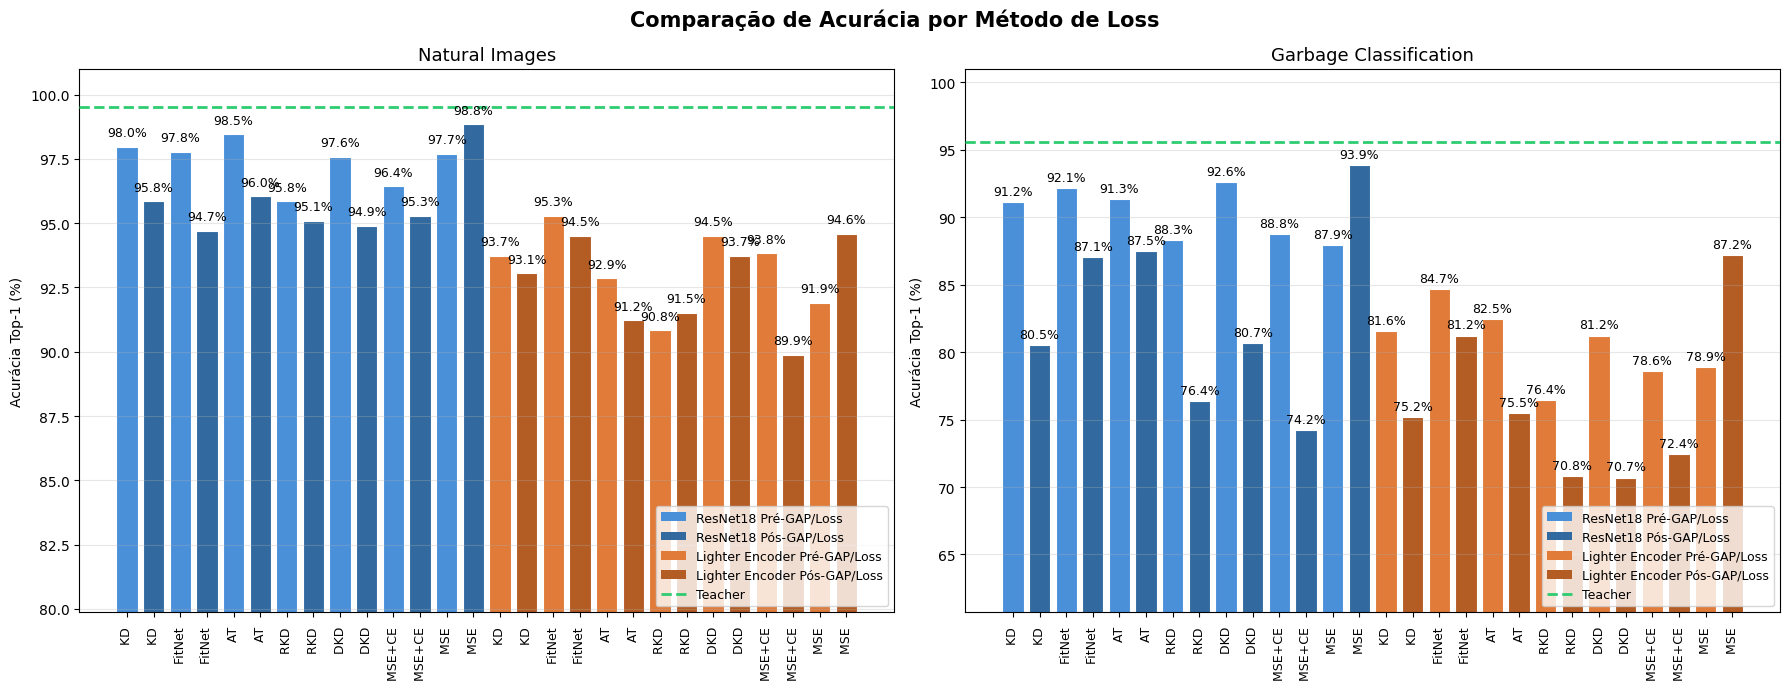

💾 Salvo: comparison_bars.png


In [30]:
def plot_comparison_bars(results_nat, results_garb):
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle("Comparação de Acurácia por Método de Loss",
                 fontsize=15, fontweight="bold")

    # Novas cores para Pré e Pós, usando tons de azul para ResNet18 e laranja para Lighter
    colors = {
        "ResNet18_Pre":  "#4A90D9",   # Azul original para ResNet18 Pré
        "ResNet18_Post": "#326AA0",   # Azul mais escuro para ResNet18 Pós
        "Lighter_Pre":   "#E07B39",   # Laranja original para Lighter Pré
        "Lighter_Post":  "#B35C24",   # Laranja mais escuro para Lighter Pós
        "Teacher":       "#2ECC71"    # Verde para Teacher
    }

    for ax, results, ds_name in zip(
            axes,
            [results_nat, results_garb],
            ["Natural Images", "Garbage Classification"]):

        if not results:
            ax.set_title(f"{ds_name} — sem dados")
            continue

        # Separa teacher dos estudantes
        student_names = [n for n in results if n != "Teacher"]
        accs = [results[n]["accuracy"] * 100 for n in student_names]

        bar_colors = [
            colors["ResNet18_Pre"]  if "ResNet18) Pré" in n else
            colors["ResNet18_Post"] if "ResNet18) Pós" in n else
            colors["Lighter_Pre"]   if "Lighter) Pré"  in n else
            colors["Lighter_Post"]  if "Lighter) Pós"  in n else
            "#AAAAAA" # Cor padrão para modelos não categorizados
            for n in student_names
        ]

        bars = ax.bar(range(len(student_names)), accs,
                      color=bar_colors, edgecolor="white", linewidth=0.8)

        # Linha do Teacher
        if "Teacher" in results:
            t_acc = results["Teacher"]["accuracy"] * 100
            ax.axhline(t_acc, color=colors["Teacher"], linestyle="--",
                       linewidth=2, label=f"Teacher ({t_acc:.1f}%)", zorder=3)

        ax.set_title(ds_name, fontsize=13)
        ax.set_ylabel("Acurácia Top-1 (%)", fontsize=10)
        ax.set_xticks(range(len(student_names)))
        ax.set_xticklabels(
            [n.replace(" (ResNet18) Pré", "").replace(" (Lighter) Pré", "").replace(" (ResNet18) Pós", "").replace(" (Lighter) Pós", "").replace("[nat]", "").replace("[garb]", "").replace("-GAP", "")
             for n in student_names],
            rotation=90, ha="center", fontsize=9)

        ymin = max(0, min(accs) - 10) if accs else 70
        ax.set_ylim(ymin, 101)
        ax.grid(axis="y", alpha=0.3)

        for bar, val in zip(bars, accs):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f"{val:.1f}%", ha="center", va="bottom",
                    fontsize=9)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=colors["ResNet18_Pre"],  label="ResNet18 Pré-GAP/Loss"),
            Patch(facecolor=colors["ResNet18_Post"], label="ResNet18 Pós-GAP/Loss"),
            Patch(facecolor=colors["Lighter_Pre"],   label="Lighter Encoder Pré-GAP/Loss"),
            Patch(facecolor=colors["Lighter_Post"],  label="Lighter Encoder Pós-GAP/Loss"),
            plt.Line2D([0], [0], color=colors["Teacher"], linestyle="--",
                       linewidth=2, label="Teacher"),
        ]
        ax.legend(handles=legend_elements, loc="lower right", fontsize=9)

    plt.tight_layout()
    plt.savefig("comparison_bars.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Salvo: comparison_bars.png")

plot_comparison_bars(results_nat, results_garb)

## 16. Matrizes de Confusão

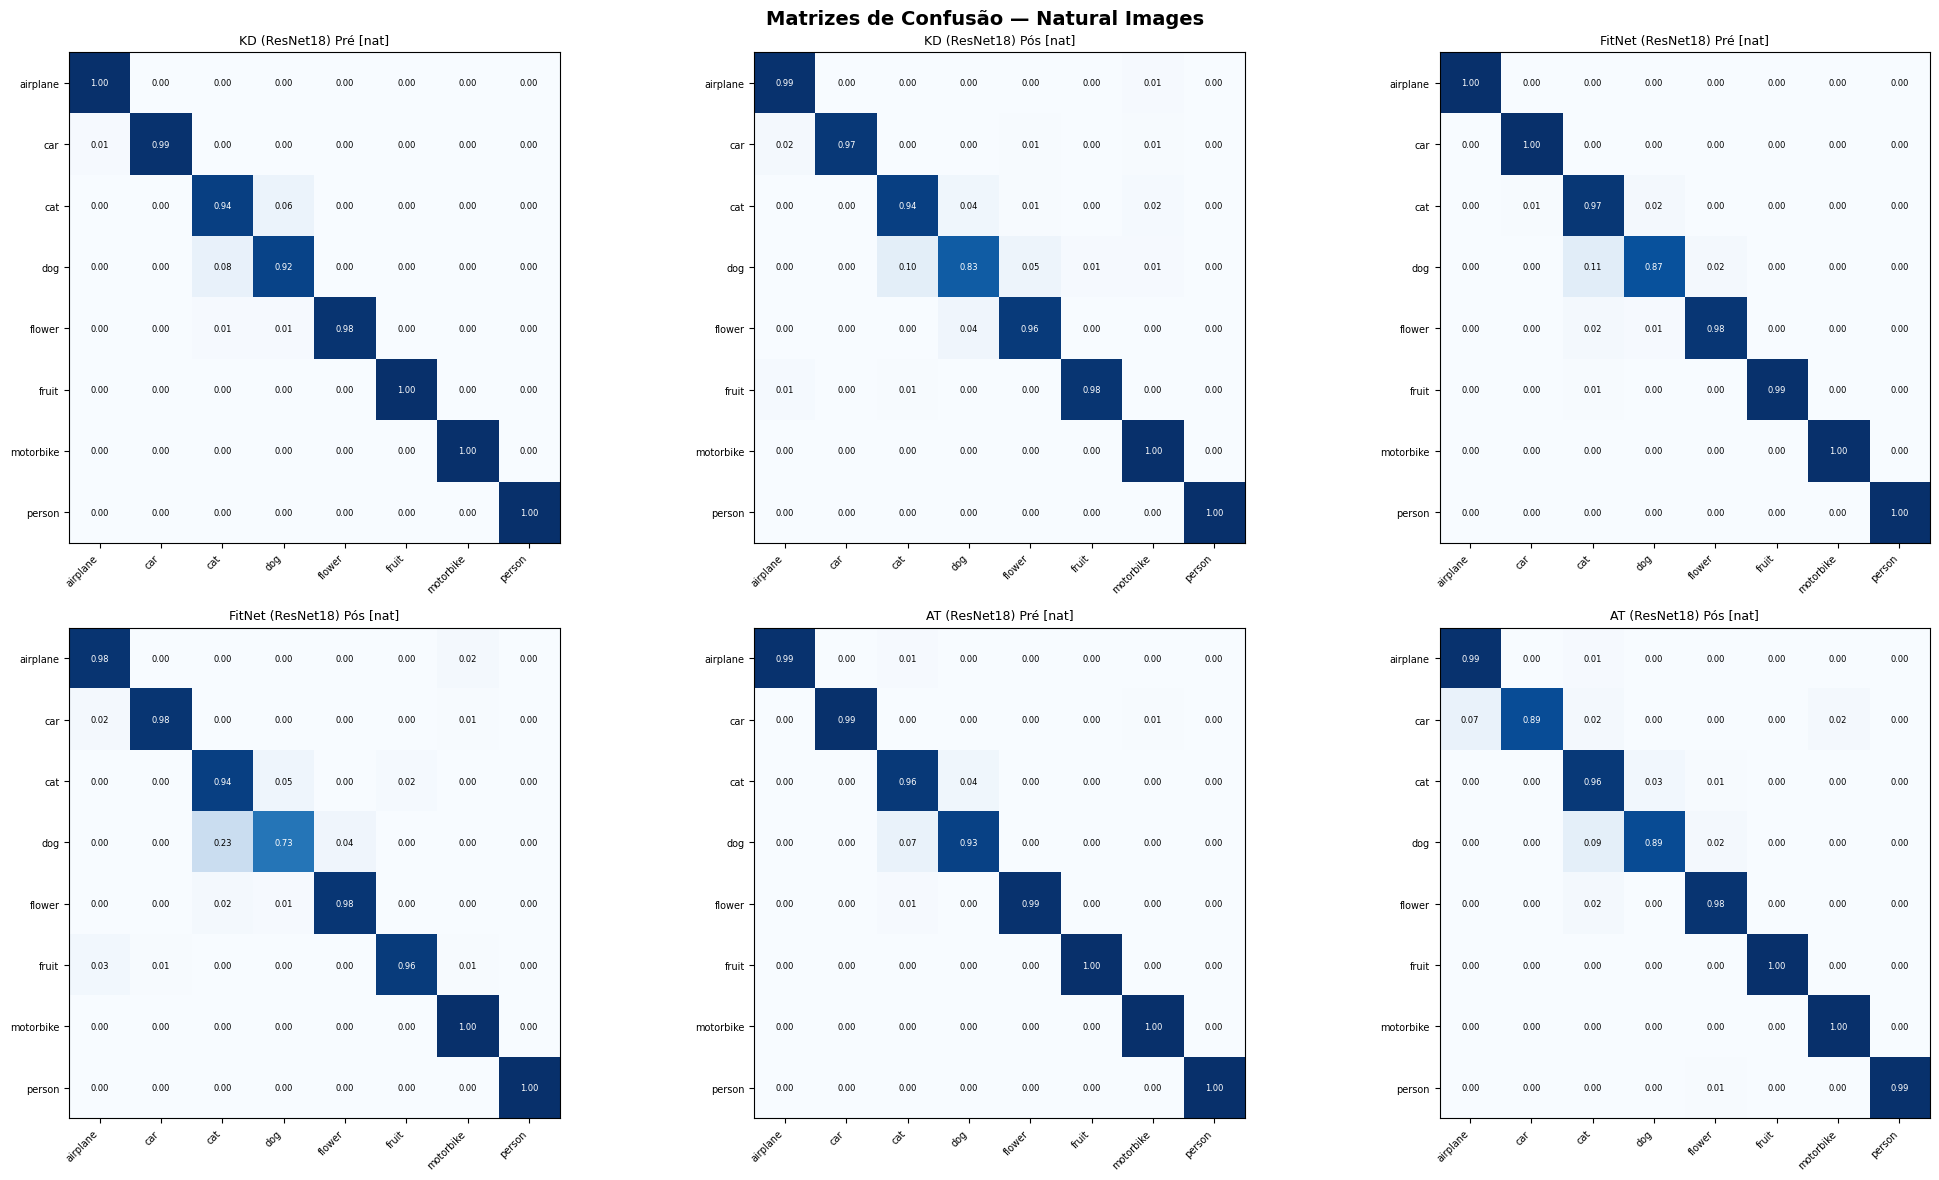

💾 Salvo: confusion_Natural_Images.png


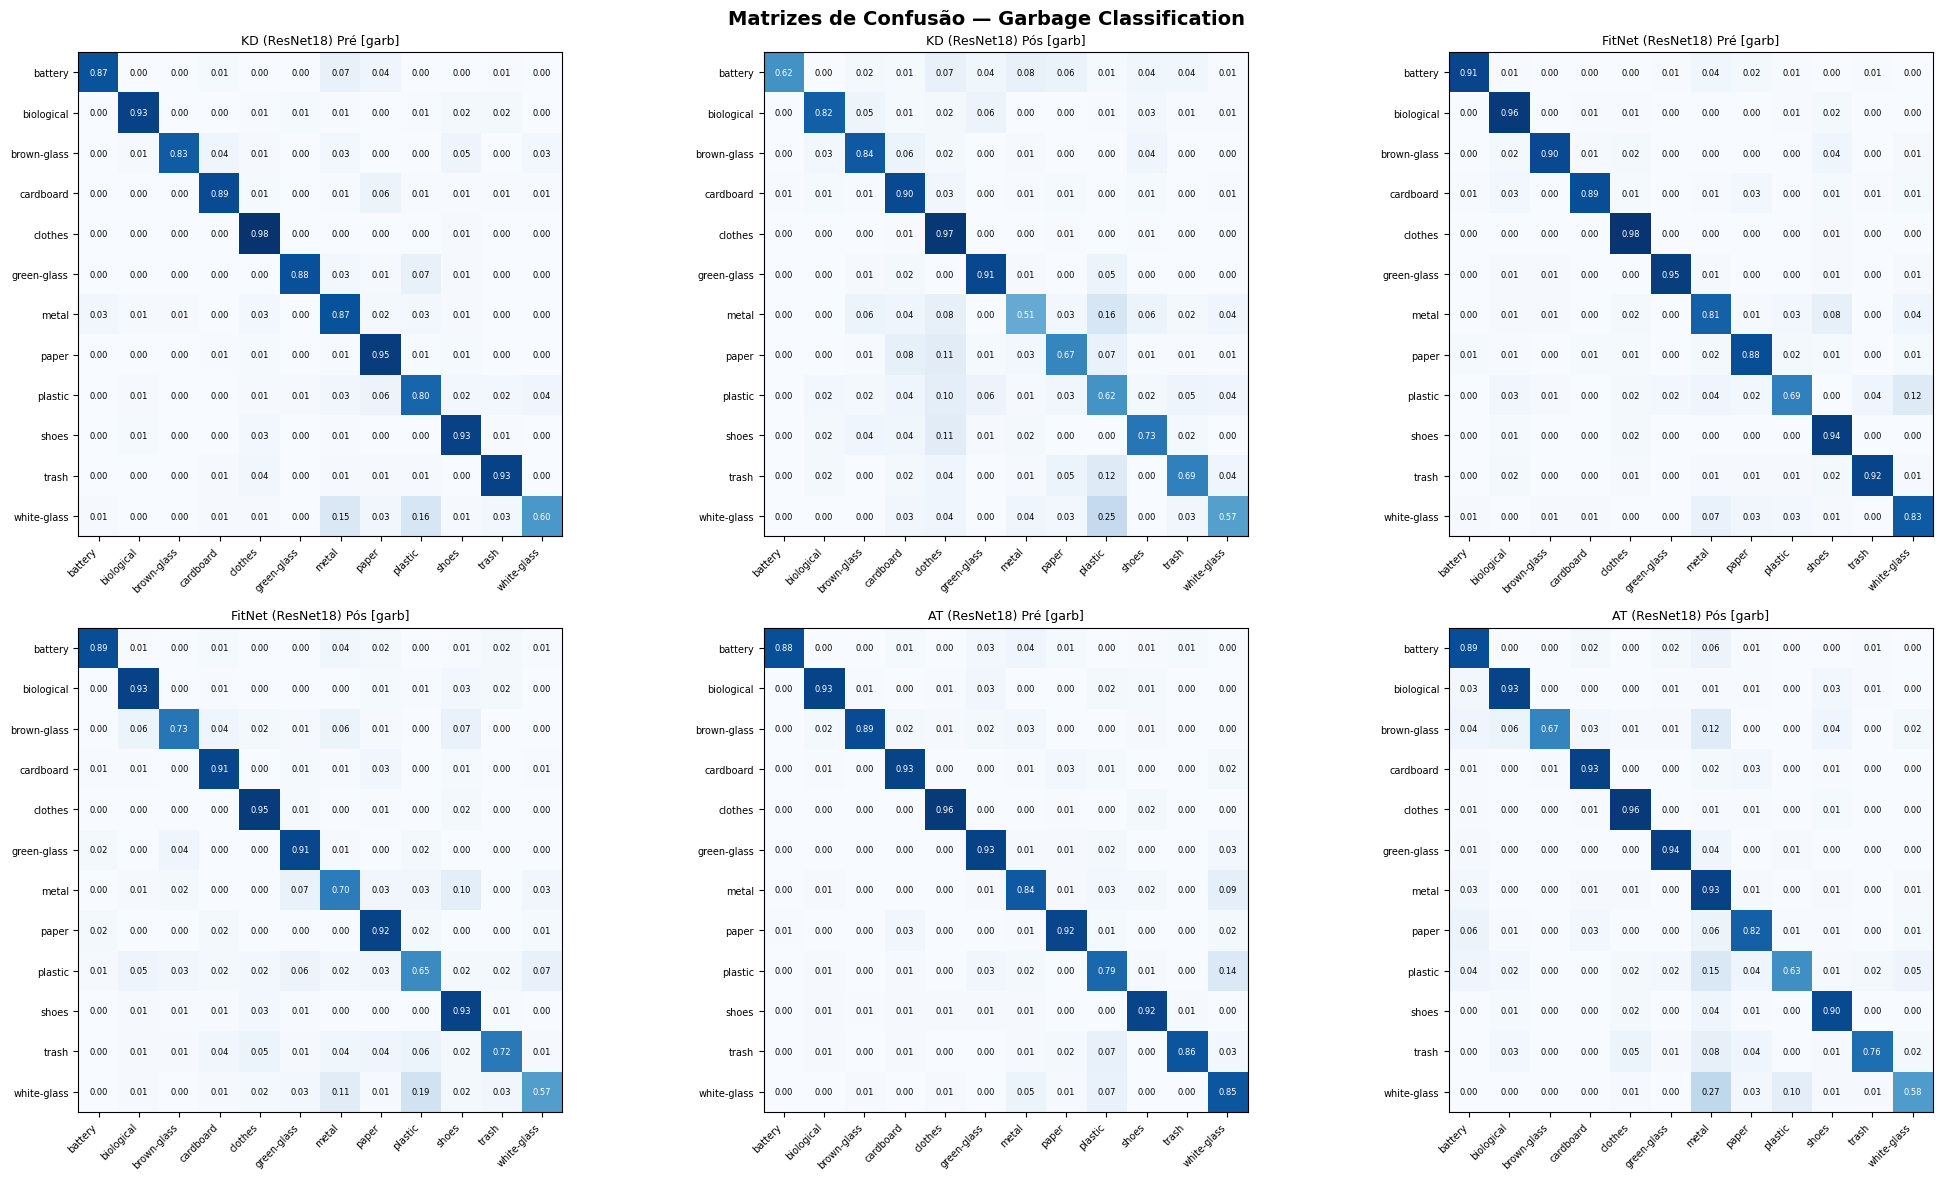

💾 Salvo: confusion_Garbage_Classification.png


In [31]:
def plot_confusions(results, classes, title, max_models=6):
    if not results:
        return

    names = [n for n in results if n != "Teacher"][:max_models]
    ncols = 3
    nrows = -(-len(names) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"Matrizes de Confusão — {title}", fontsize=14, fontweight="bold")

    for ax, name in zip(axes, names):
        cm      = confusion_matrix(results[name]["labels"], results[name]["preds"])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        ax.imshow(cm_norm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
        ax.set_title(name, fontsize=9)
        ticks = np.arange(len(classes))
        ax.set_xticks(ticks); ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=7)
        ax.set_yticks(ticks); ax.set_yticklabels(classes, fontsize=7)
        for i in range(len(classes)):
            for j in range(len(classes)):
                ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                        color="white" if cm_norm[i,j] > 0.5 else "black", fontsize=6)

    for ax in axes[len(names):]:
        ax.axis("off")
    plt.tight_layout()
    fname = f"confusion_{title.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"💾 Salvo: {fname}")

plot_confusions(results_nat,  classes_nat,  "Natural Images",         max_models=6)
plot_confusions(results_garb, classes_garb, "Garbage Classification", max_models=6)


## 18. Análise de Eficiência Computacional

In [32]:
def compute_efficiency(models_dict, input_size=(1, 3, 224, 224)):
    rows  = []
    dummy = torch.randn(*input_size).to(device)
    for name, model in models_dict.items():
        try:
            params       = sum(p.numel() for p in model.parameters()) / 1e6
            params_train = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
            try:
                flops, _ = profile(model, inputs=(dummy,), verbose=False)
                gflops   = flops / 1e9
            except Exception:
                gflops   = float("nan")
            rows.append({
                "Modelo":                     name,
                "Parâmetros Total (M)":        round(params, 2),
                "Parâmetros Treináveis (M)":   round(params_train, 2),
                "GFLOPs":                      round(gflops, 3),
            })
        except Exception as e:
            rows.append({"Modelo": name, "Parâmetros Total (M)": "ERR", "GFLOPs": str(e)})
    return pd.DataFrame(rows)

all_models_for_eff = {**loaded_nat}   # usa Natural como referência de arquiteturas
df_eff = compute_efficiency(all_models_for_eff)
print("\n Eficiência Computacional:")
display(df_eff)



 Eficiência Computacional:


,Modelo,Parâmetros Total (M),Parâmetros Treináveis (M),GFLOPs
0,KD (ResNet18) Pré [nat],14.61,14.59,1.991
1,KD (ResNet18) Pós [nat],16.44,16.43,1.829
2,FitNet (ResNet18) Pré [nat],14.61,14.59,1.991
3,FitNet (ResNet18) Pós [nat],16.44,16.43,1.829
4,AT (ResNet18) Pré [nat],14.61,14.59,1.991
5,AT (ResNet18) Pós [nat],16.44,16.43,1.829
6,RKD (ResNet18) Pré [nat],14.61,14.59,1.991
7,RKD (ResNet18) Pós [nat],16.44,16.43,1.829
8,DKD (ResNet18) Pré [nat],14.61,14.59,1.991
9,DKD (ResNet18) Pós [nat],16.44,16.43,1.829


## 20. Resumo Final — Ranking dos Melhores Modelos

In [33]:
def print_summary(results_nat, results_garb):
    print("=" * 70)
    print("              RESUMO FINAL — RANKING DOS MODELOS")
    print("=" * 70)
    for results, ds_name in [(results_nat, "Natural Images"), (results_garb, "Garbage Classification")]:
        if not results:
            continue
        print(f"\n📌 {ds_name}")
        print("-" * 70)
        sorted_names = sorted(results, key=lambda n: results[n]["accuracy"], reverse=True)
        for rank, name in enumerate(sorted_names, 1):
            r = results[name]
            marker = "🏫" if name == "Teacher" else f"{rank:2d}."
            print(f"  {marker} {name:<38} "
                  f"Acc={r['accuracy']*100:5.2f}%  "
                  f"F1={r['f1_macro']*100:5.2f}%  "
                  f"κ={r['kappa']:.3f}")
        best = [n for n in sorted_names if n != "Teacher"][0]
        print(f"\n  🥇 Melhor estudante: {best}")
        print(f"     Acurácia : {results[best]['accuracy']*100:.2f}%")
        print(f"     F1 Macro : {results[best]['f1_macro']*100:.2f}%")
        print(f"     Kappa    : {results[best]['kappa']:.4f}")

print_summary(results_nat, results_garb)

              RESUMO FINAL — RANKING DOS MODELOS

📌 Natural Images
----------------------------------------------------------------------
  🏫 Teacher                                Acc=99.52%  F1=99.49%  κ=0.994
   2. MSE (ResNet18) Pós [nat]               Acc=98.84%  F1=98.80%  κ=0.987
   3. AT (ResNet18) Pré [nat]                Acc=98.46%  F1=98.41%  κ=0.982
   4. KD (ResNet18) Pré [nat]                Acc=97.97%  F1=97.92%  κ=0.977
   5. FitNet (ResNet18) Pré [nat]            Acc=97.78%  F1=97.71%  κ=0.975
   6. MSE (ResNet18) Pré [nat]               Acc=97.68%  F1=97.59%  κ=0.973
   7. DKD (ResNet18) Pré [nat]               Acc=97.59%  F1=97.54%  κ=0.972
   8. MSE+CE (ResNet18) Pré [nat]            Acc=96.43%  F1=96.33%  κ=0.959
   9. AT (ResNet18) Pós [nat]                Acc=96.04%  F1=96.08%  κ=0.955
  10. KD (ResNet18) Pós [nat]                Acc=95.85%  F1=95.65%  κ=0.952
  11. RKD (ResNet18) Pré [nat]               Acc=95.85%  F1=95.74%  κ=0.952
  12. MSE+CE (ResNet18) Pós 

## Salvar em JSON

In [34]:
import os

all_summary = {}
for name in set(list(results_nat.keys()) + list(results_garb.keys())):
    entry = {}
    for key, res_dict in [("natural", results_nat), ("garbage", results_garb)]:
        if name in res_dict:
            entry[key] = {
                k: float(v)
                for k, v in res_dict[name].items()
                if isinstance(v, (int, float, np.floating))
            }
    all_summary[name] = entry

with open(os.path.join(PATH, "results_summary.json"), "w") as f:
    json.dump(all_summary, f, indent=2)
print(f"\n Resultados salvos em: {os.path.join(PATH, 'results_summary.json')}")


 Resultados salvos em: /content/drive/My Drive/Colab Notebooks/MO434/results_summary.json
